# Import de bibliotecas


In [ ]:
!pip install kneed

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler, RobustScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from kneed import KneeLocator
from yellowbrick.cluster import SilhouetteVisualizer
from itertools import combinations
import plotly.express as px
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE
from sklearn.neighbors import KNeighborsClassifier
from kneed import knee_locator


#Load do DF

In [2]:
import pandas as pd

# Carrega o dataset
df = pd.read_csv("dataset_processed.csv", encoding='utf-8', low_memory=True)

# Comparativo de Desempenho dos Modelos

Nesta seção, comparamos as métricas de desempenho dos modelos Random Forest, SVM e XGBoost no conjunto de teste para avaliar qual deles obteve os melhores resultados na previsão de popularidade de músicas.

Using hardcoded optimal_k: 7

Perfil médio dos clusters (em features processadas):


,duration_ms,explicit,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,...,key_8,key_9,key_10,key_11,mode_1,time_signature_1,time_signature_3,time_signature_4,time_signature_5,is_popular
cluster,,,,,,,,,,,,,,,,,,,,,
0,-0.154962,-0.305842,0.761860,0.339489,0.370808,-0.035629,-0.289896,-0.474560,-0.258926,0.981194,...,0.063473,0.104569,0.065631,0.084913,0.621458,0.002862,0.025145,0.964158,0.007834,0.135954
1,-0.138634,-0.304452,-0.165272,-1.020802,-0.408845,-0.294623,1.079200,-0.395516,-0.302606,-0.264790,...,0.052073,0.101878,0.065803,0.063795,0.718912,0.013795,0.161593,0.802785,0.021438,0.110233
2,0.704803,-0.302692,0.184826,0.393839,-0.009147,-0.165448,-0.666413,1.814849,-0.266723,-0.472167,...,0.067504,0.080388,0.083581,0.096575,0.535734,0.008369,0.051646,0.929854,0.010021,0.032155
3,0.067893,-0.296882,-0.269042,0.406196,0.182528,0.363369,0.034315,-0.321393,2.735489,0.111252,...,0.040630,0.120100,0.051906,0.083587,0.667263,0.011455,0.079828,0.890281,0.017362,0.046716
4,-0.229366,3.256286,0.368624,0.333910,0.350751,1.132056,-0.272625,-0.384598,0.143153,0.001572,...,0.072251,0.086788,0.069085,0.090961,0.588227,0.009067,0.064191,0.883851,0.042890,0.176885
5,-0.115561,-0.301222,-1.250398,-1.809533,-2.425581,-0.320013,1.569914,1.804393,-0.287941,-1.098169,...,0.055556,0.099322,0.066537,0.043766,0.652455,0.035853,0.251130,0.633236,0.057978,0.068960
6,0.057999,-0.305842,-0.517402,0.689117,0.599158,-0.065749,-0.741965,-0.414967,-0.112113,-0.379717,...,0.066389,0.107449,0.057271,0.085101,0.617998,0.004529,0.059416,0.927294,0.008641,0.120679



Distribuição de Popularidade (proporção) por Cluster:


is_popular,0,1
cluster,,
0,0.864046,0.135954
1,0.889767,0.110233
2,0.967845,0.032155
3,0.953284,0.046716
4,0.823115,0.176885
5,0.931040,0.068960
6,0.879321,0.120679


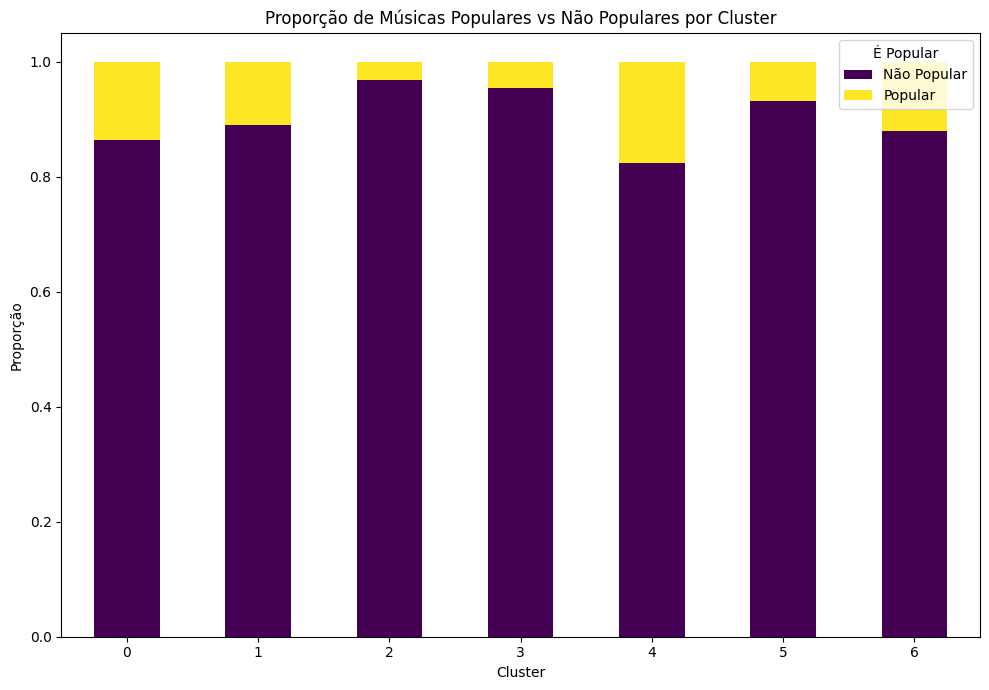

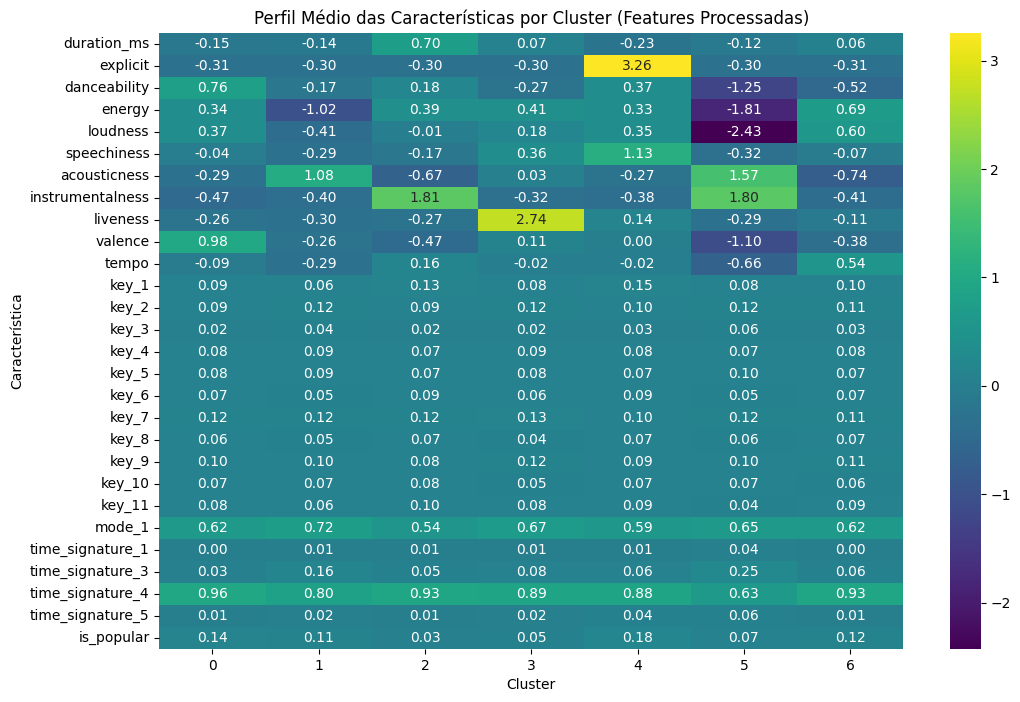

In [20]:
# Aprofundar a Análise de Clusterização

# Assumindo que X e y estão definidos a partir das células de pré-processamento
# Assumindo que optimal_k (número ótimo de clusters) foi determinado na célula jk6tSMxyTfDD

# 1. Aplicar K-Means com o número ótimo de clusters
from sklearn.cluster import KMeans

# Using the optimal_k determined in cell jk6tSMxyTfDD (assuming it's 7 based on previous output)
# It's better to get the value from the variable if it exists. Let's assume optimal_k is available.
# If not, we would need to re-run the elbow method cell or use the hardcoded value 7.
# For robustness, let's use the value from kneedle.knee if kneedle is available, otherwise default to 7.
try:
    optimal_k = int(kneedle.elbow)
    print(f"Using optimal_k from KneeLocator: {optimal_k}")
except NameError:
    optimal_k = 7
    print(f"Using hardcoded optimal_k: {optimal_k}")


kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init='auto')
clusters = kmeans.fit_predict(X) # Fit on the complete preprocessed data X

# 2. Adicionar os rótulos dos clusters ao DataFrame original ou pré-processado
# Let's add to the preprocessed DataFrame X for analysis
X_clustered = X.copy()
X_clustered['cluster'] = clusters
X_clustered['is_popular'] = y # Add the target variable for analysis

# 3. Analisar as características médias de cada cluster
# We can group by cluster and calculate the mean of all features in X, plus popularity
cluster_profile = X_clustered.groupby('cluster').mean()

print("\nPerfil médio dos clusters (em features processadas):")
display(cluster_profile)

# 4. Analisar a distribuição de popularidade por cluster
popularity_by_cluster = X_clustered.groupby('cluster')['is_popular'].value_counts(normalize=True).unstack().fillna(0)

print("\nDistribuição de Popularidade (proporção) por Cluster:")
display(popularity_by_cluster)

# 5. Visualizar a distribuição de popularidade por cluster (usando um gráfico de barras empilhadas ou agrupadas)
popularity_by_cluster.plot(kind='bar', stacked=True, figsize=(10, 7), cmap='viridis')
plt.title('Proporção de Músicas Populares vs Não Populares por Cluster')
plt.xlabel('Cluster')
plt.ylabel('Proporção')
plt.xticks(rotation=0)
plt.legend(title='É Popular', labels=['Não Popular', 'Popular'])
plt.tight_layout()
plt.show()


# Optional: Visualize mean feature values by cluster using a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(cluster_profile.T, annot=True, cmap='viridis', fmt='.2f')
plt.title('Perfil Médio das Características por Cluster (Features Processadas)')
plt.xlabel('Cluster')
plt.ylabel('Característica')
plt.show()

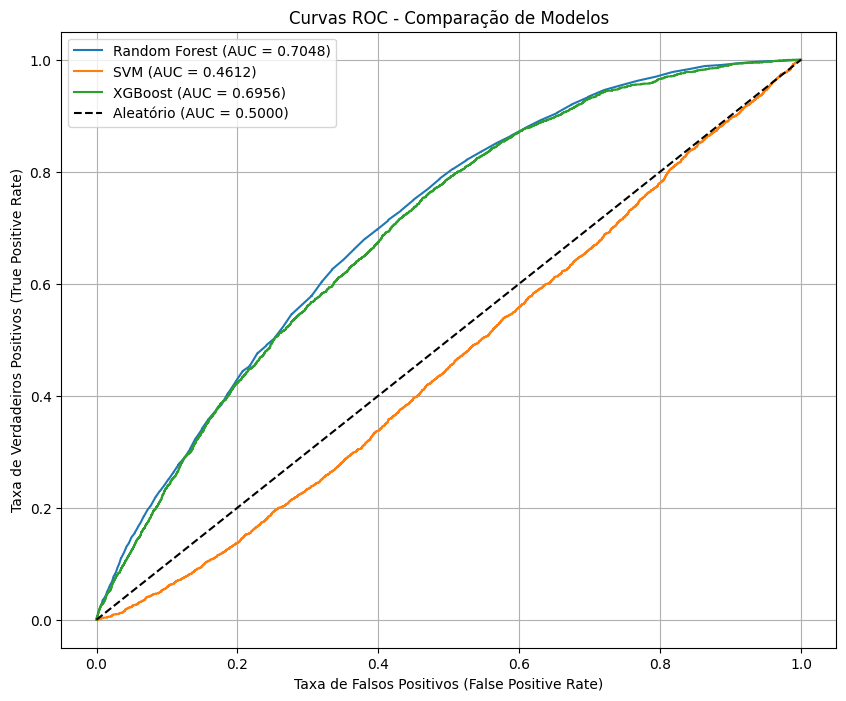

AUC para Random Forest: 0.7048
AUC para SVM: 0.4612
AUC para XGBoost: 0.6956


In [80]:
# Calcular probabilidades de previsão para a classe positiva (Popular) no conjunto de teste

# Random Forest
y_probs_rf = model_rf.predict_proba(X_test)[:, 1]

# SVM
# Predict probabilities for the positive class
# Ensure X_test is converted to float numpy array for consistency with training
y_probs_svm = svm_model.predict_proba(X_test.values.astype(float))[:, 1]

# XGBoost
# Para XGBoostClassifier com objective='binary:logistic', predict_proba já retorna probabilidades
y_probs_xgb = xgb_model.predict_proba(X_test)[:, 1]


# Calcular a curva ROC e a AUC para cada modelo
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_probs_rf)
auc_rf = roc_auc_score(y_test, y_probs_rf)

fpr_svm, tpr_svm, thresholds_svm = roc_curve(y_test, y_probs_svm)
auc_svm = roc_auc_score(y_test, y_probs_svm)

fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(y_test, y_probs_xgb)
auc_xgb = roc_auc_score(y_test, y_probs_xgb)


# Plotar as curvas ROC
plt.figure(figsize=(10, 8))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.4f})')
plt.plot(fpr_svm, tpr_svm, label=f'SVM (AUC = {auc_svm:.4f})')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc_xgb:.4f})')

# Plotar a linha de base (random classifier)
plt.plot([0, 1], [0, 1], 'k--', label='Aleatório (AUC = 0.5000)')

plt.xlabel('Taxa de Falsos Positivos (False Positive Rate)')
plt.ylabel('Taxa de Verdadeiros Positivos (True Positive Rate)')
plt.title('Curvas ROC - Comparação de Modelos')
plt.legend()
plt.grid(True)
plt.show()

print(f"AUC para Random Forest: {auc_rf:.4f}")
print(f"AUC para SVM: {auc_svm:.4f}")
print(f"AUC para XGBoost: {auc_xgb:.4f}")